# 102 - Voronoi 分割: ピボットの汎化性能実験

## 目的

NB100-101 で確立したベスト構成（256ピボット、assign=2、cosine空間）の **ピボットが未知データに対しても安定して機能するか** を検証する。

### 実験設計

1. **実験1: Train/Test 分割テスト**
   - 75K件を 60%学習 / 40%テスト にランダム分割
   - 学習セット（~45K件）で k-means ピボットを学習
   - テストセット（~30K件）を学習済みピボットに割り当て
   - 両セットのクエリで検索精度を比較

2. **実験2: 増分データ追加シミュレーション**
   - 50K件でピボット学習 → 残り25K件を新規追加
   - ピボット再学習なしで精度が維持されるか確認

### 成功基準
- テストセットの BF-R@30 が学習セットの **95%以上** を維持
- 増分追加後もピボットサイズの Gini 係数が大きく変わらない

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path
from sklearn.cluster import MiniBatchKMeans

DB_PATH = Path("../data/images.duckdb")
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.cluster_id, f.image_id
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]
image_ids = [r[3] for r in rows]

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normed = embeddings / norms

N_DATA = len(face_ids)
print(f"Total faces: {N_DATA}")
print(f"Embedding dim: {embeddings_normed.shape[1]}")

# クエリ用クラスタ構築
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

MIN_CLUSTER_SIZE = 3
valid_clusters = {cid: members for cid, members in cluster_members.items() if len(members) >= MIN_CLUSTER_SIZE}
print(f"Valid clusters (size >= {MIN_CLUSTER_SIZE}): {len(valid_clusters)}")
print(f"Total clustered faces: {sum(len(m) for m in valid_clusters.values())}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75162
Embedding dim: 512
Valid clusters (size >= 3): 23
Total clustered faces: 162


In [2]:
def build_queries(indices_subset, cluster_members_global, embeddings_normed_full):
    """指定インデックスのサブセットからクエリを構築する。
    
    indices_subset: このセットに含まれるインデックス集合
    cluster_members_global: グローバルなクラスタメンバー情報
    embeddings_normed_full: 全データの正規化済み embedding
    """
    subset_set = set(indices_subset)
    queries = []
    for cid in sorted(valid_clusters.keys()):
        members_in_subset = [m for m in valid_clusters[cid] if m in subset_set]
        if len(members_in_subset) < 2:
            continue
        for q_idx in members_in_subset:
            gt_indices = [m for m in members_in_subset if m != q_idx]
            queries.append({"query_idx": q_idx, "cluster_id": cid, "gt_indices": gt_indices})
    return queries


def compute_ground_truth(queries, embeddings_normed, data_indices, max_k=50):
    """ブルートフォース Ground Truth を計算（data_indices 内のみ）"""
    data_set = set(data_indices)
    gt = {}
    for qi, q in enumerate(queries):
        q_emb = embeddings_normed[q["query_idx"]]
        # data_indices の中だけで検索
        idx_arr = np.array(data_indices)
        sims = embeddings_normed[idx_arr] @ q_emb
        # 自分自身を除外
        mask = idx_arr != q["query_idx"]
        idx_arr = idx_arr[mask]
        sims = sims[mask]
        top_order = np.argsort(-sims)[:max_k]
        gt[qi] = {"indices": idx_arr[top_order], "scores": sims[top_order]}
    return gt


def run_voronoi_search_with_pivots(embeddings_normed, data_indices, queries, ground_truth,
                                    centroids_normed, n_assign, n_top_search, top_k_values):
    """事前計算済みピボットを使って Voronoi 検索を実行"""
    data_indices_arr = np.array(data_indices)
    data_embs = embeddings_normed[data_indices_arr]
    
    # 全データの全ピボットとの類似度
    all_pivot_sims = data_embs @ centroids_normed.T
    
    # マルチピボット割り当て
    pivot_to_indices = {}
    for i_local, i_global in enumerate(data_indices):
        top_pivots = np.argsort(-all_pivot_sims[i_local])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i_global)
    
    pivot_sizes = [len(v) for v in pivot_to_indices.values()]
    
    # 検索シミュレーション
    bf_recalls = {k: [] for k in top_k_values}
    cluster_recalls = {k: [] for k in top_k_values}
    candidate_counts = []
    
    for qi, q in enumerate(queries):
        q_emb = embeddings_normed[q["query_idx"]]
        pivot_sims = centroids_normed @ q_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top_search]
        
        candidates_set = set()
        for pid in top_pivot_ids:
            if pid in pivot_to_indices:
                candidates_set.update(pivot_to_indices[pid])
        candidates = list(candidates_set)
        candidate_counts.append(len(candidates))
        
        cand_indices = np.array(candidates)
        cand_sims = embeddings_normed[cand_indices] @ q_emb
        self_mask = cand_indices != q["query_idx"]
        cand_indices = cand_indices[self_mask]
        cand_sims = cand_sims[self_mask]
        
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]
        
        for k in top_k_values:
            result_set = set(result_indices[:k])
            bf_set = set(ground_truth[qi]["indices"][:k])
            bf_r = len(result_set & bf_set) / k if k > 0 else 0.0
            bf_recalls[k].append(bf_r)
            
            cluster_gt = set(q["gt_indices"])
            found = len(result_set & cluster_gt)
            cr = found / len(cluster_gt) if cluster_gt else 0.0
            cluster_recalls[k].append(cr)
        
    return {
        "pivot_sizes": pivot_sizes,
        "mean_candidates": np.mean(candidate_counts),
        "median_candidates": np.median(candidate_counts),
        "max_candidates": np.max(candidate_counts),
        "p95_candidates": np.percentile(candidate_counts, 95),
        "bf_recall": {k: np.mean(v) for k, v in bf_recalls.items()},
        "cluster_recall": {k: np.mean(v) for k, v in cluster_recalls.items()},
        "candidate_counts": candidate_counts,
    }

TOP_K_VALUES = [1, 5, 10, 20, 30, 50]
MAX_K = max(TOP_K_VALUES)
print("ユーティリティ関数を定義しました")

ユーティリティ関数を定義しました


## 実験1: Train/Test 分割テスト

75K件を 60%学習 / 40%テスト にランダム分割し、学習セットで作ったピボットがテストセットでも同等の精度を出せるか検証する。

In [3]:
# --- Train/Test 分割 ---
np.random.seed(42)
all_indices = np.arange(N_DATA)
np.random.shuffle(all_indices)

train_size = int(N_DATA * 0.6)
train_indices = sorted(all_indices[:train_size].tolist())
test_indices = sorted(all_indices[train_size:].tolist())

print(f"Train set: {len(train_indices)} ({len(train_indices)/N_DATA*100:.1f}%)")
print(f"Test set:  {len(test_indices)} ({len(test_indices)/N_DATA*100:.1f}%)")

# 各セットのクエリ構築
train_queries = build_queries(train_indices, valid_clusters, embeddings_normed)
test_queries = build_queries(test_indices, valid_clusters, embeddings_normed)
print(f"\nTrain queries: {len(train_queries)}")
print(f"Test queries:  {len(test_queries)}")

# Ground Truth 計算
train_gt = compute_ground_truth(train_queries, embeddings_normed, train_indices, MAX_K)
test_gt = compute_ground_truth(test_queries, embeddings_normed, test_indices, MAX_K)
print("Ground truth computed.")

Train set: 45097 (60.0%)
Test set:  30065 (40.0%)

Train queries: 82
Test queries:  71


Ground truth computed.


In [4]:
# --- 学習セットで k-means ピボット学習 ---
N_PIVOTS = 256
N_ASSIGN = 2

train_embs = embeddings_normed[train_indices]
kmeans = MiniBatchKMeans(n_clusters=N_PIVOTS, random_state=42, batch_size=2048, n_init=3)
kmeans.fit(train_embs)
centroids = kmeans.cluster_centers_
centroids_normed = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)

print(f"ピボット学習完了: {N_PIVOTS} pivots from {len(train_indices)} train samples")
print(f"Centroid shape: {centroids_normed.shape}")

# --- 学習セットでの検索精度 ---
TOP_SEARCH_LIST = [2, 3, 4, 5]
train_results = {}
for n_top in TOP_SEARCH_LIST:
    print(f"\n  Train: top={n_top} ... ", end="", flush=True)
    t0 = time.perf_counter()
    res = run_voronoi_search_with_pivots(
        embeddings_normed, train_indices, train_queries, train_gt,
        centroids_normed, N_ASSIGN, n_top, TOP_K_VALUES
    )
    elapsed = time.perf_counter() - t0
    train_results[n_top] = res
    print(f"cands={res['mean_candidates']:.0f} BF-R@30={res['bf_recall'][30]:.4f} "
          f"CR@30={res['cluster_recall'][30]:.4f} ({elapsed:.1f}s)")

# --- テストセットでの検索精度（同じピボットを使用） ---
test_results = {}
for n_top in TOP_SEARCH_LIST:
    print(f"\n  Test:  top={n_top} ... ", end="", flush=True)
    t0 = time.perf_counter()
    res = run_voronoi_search_with_pivots(
        embeddings_normed, test_indices, test_queries, test_gt,
        centroids_normed, N_ASSIGN, n_top, TOP_K_VALUES
    )
    elapsed = time.perf_counter() - t0
    test_results[n_top] = res
    print(f"cands={res['mean_candidates']:.0f} BF-R@30={res['bf_recall'][30]:.4f} "
          f"CR@30={res['cluster_recall'][30]:.4f} ({elapsed:.1f}s)")

ピボット学習完了: 256 pivots from 45097 train samples
Centroid shape: (256, 512)

  Train: top=2 ... 

cands=798 BF-R@30=0.7492 CR@30=0.5007 (0.4s)

  Train: top=3 ... 

cands=1187 BF-R@30=0.7902 CR@30=0.5024 (0.4s)

  Train: top=4 ... 

cands=1583 BF-R@30=0.8150 CR@30=0.5122 (0.4s)

  Train: top=5 ... 

cands=1947 BF-R@30=0.8309 CR@30=0.5257 (0.5s)

  Test:  top=2 ... 

cands=574 BF-R@30=0.6577 CR@30=0.4824 (0.3s)

  Test:  top=3 ... 

cands=836 BF-R@30=0.7183 CR@30=0.5378 (0.3s)

  Test:  top=4 ... 

cands=1105 BF-R@30=0.7460 CR@30=0.5477 (0.4s)

  Test:  top=5 ... 

cands=1372 BF-R@30=0.7695 CR@30=0.5618 (0.3s)


In [5]:
# --- Train vs Test 比較テーブル ---
rows = []
for n_top in TOP_SEARCH_LIST:
    tr = train_results[n_top]
    te = test_results[n_top]
    ratio_bf30 = te["bf_recall"][30] / tr["bf_recall"][30] if tr["bf_recall"][30] > 0 else 0
    ratio_cr30 = te["cluster_recall"][30] / tr["cluster_recall"][30] if tr["cluster_recall"][30] > 0 else 0
    rows.append({
        "top_k": n_top,
        "train_cands": tr["mean_candidates"],
        "test_cands": te["mean_candidates"],
        "train_BF-R@30": tr["bf_recall"][30],
        "test_BF-R@30": te["bf_recall"][30],
        "ratio_BF-R@30": ratio_bf30,
        "train_CR@30": tr["cluster_recall"][30],
        "test_CR@30": te["cluster_recall"][30],
        "ratio_CR@30": ratio_cr30,
    })

df_compare = pd.DataFrame(rows)
print(f"Train vs Test 比較 ({N_PIVOTS} pivots, assign={N_ASSIGN})")
print(f"成功基準: ratio >= 0.95 (テストが学習の95%以上)")
print("=" * 100)
display(df_compare.style.format({
    "train_cands": "{:.0f}", "test_cands": "{:.0f}",
    "train_BF-R@30": "{:.4f}", "test_BF-R@30": "{:.4f}", "ratio_BF-R@30": "{:.4f}",
    "train_CR@30": "{:.4f}", "test_CR@30": "{:.4f}", "ratio_CR@30": "{:.4f}",
}).apply(lambda x: ["background-color: #90EE90" if v >= 0.95 else "background-color: #FFB6C1" 
                     for v in x] if x.name in ["ratio_BF-R@30", "ratio_CR@30"] else [""] * len(x), axis=0))

Train vs Test 比較 (256 pivots, assign=2)
成功基準: ratio >= 0.95 (テストが学習の95%以上)


,top_k,train_cands,test_cands,train_BF-R@30,test_BF-R@30,ratio_BF-R@30,train_CR@30,test_CR@30,ratio_CR@30
0,2,798,574,0.7492,0.6577,0.8779,0.5007,0.4824,0.9636
1,3,1187,836,0.7902,0.7183,0.9090,0.5024,0.5378,1.0705
2,4,1583,1105,0.8150,0.7460,0.9153,0.5122,0.5477,1.0694
3,5,1947,1372,0.8309,0.7695,0.9261,0.5257,0.5618,1.0686


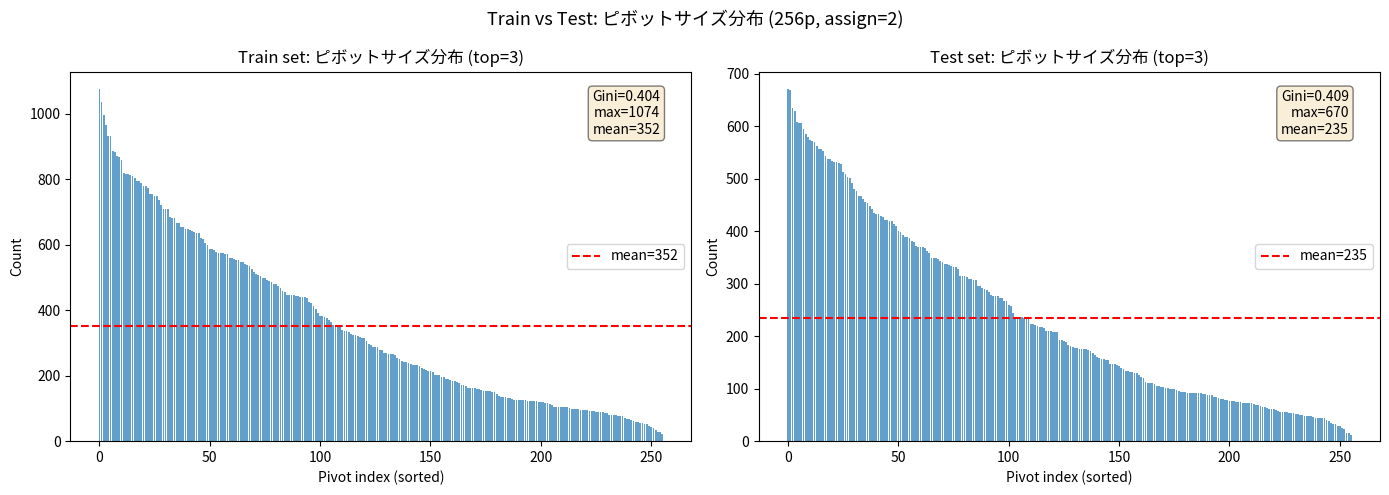

In [6]:
# --- ピボットサイズの偏り比較 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, result_dict, n_top) in zip(axes, [
    ("Train set", train_results, 3), ("Test set", test_results, 3)
]):
    sizes = sorted(result_dict[n_top]["pivot_sizes"], reverse=True)
    ax.bar(range(len(sizes)), sizes, alpha=0.7)
    ax.axhline(y=np.mean(sizes), color='red', linestyle='--', label=f'mean={np.mean(sizes):.0f}')
    ax.set_title(f'{label}: ピボットサイズ分布 (top={n_top})')
    ax.set_xlabel("Pivot index (sorted)")
    ax.set_ylabel("Count")
    
    sizes_arr = np.array(sizes, dtype=float)
    n = len(sizes_arr)
    sorted_s = np.sort(sizes_arr)
    gini = (2 * np.sum((np.arange(1, n+1)) * sorted_s) - (n + 1) * np.sum(sorted_s)) / (n * np.sum(sorted_s))
    ax.text(0.95, 0.95, f'Gini={gini:.3f}\nmax={max(sizes)}\nmean={np.mean(sizes):.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend()

plt.suptitle(f"Train vs Test: ピボットサイズ分布 ({N_PIVOTS}p, assign={N_ASSIGN})", fontsize=13)
plt.tight_layout()
plt.savefig("../data/voronoi_generalization_pivot_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

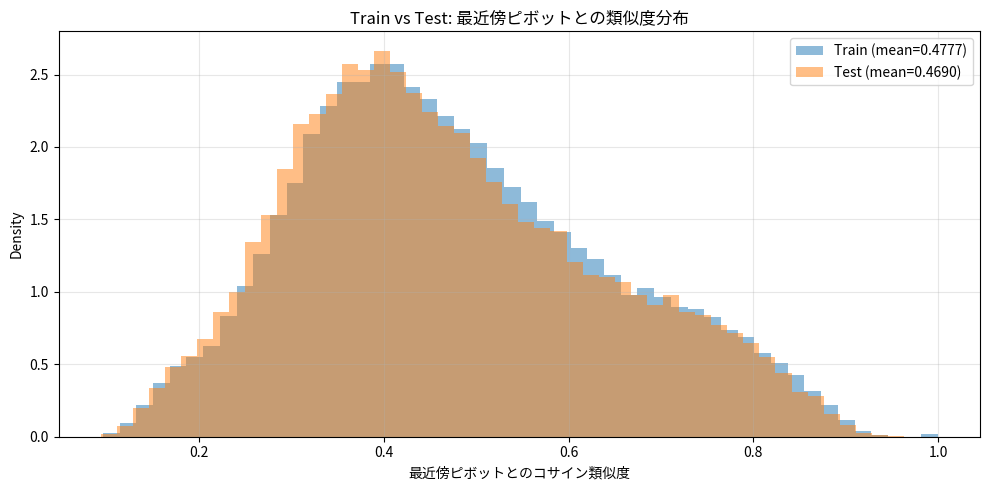

Train: mean=0.4777, std=0.1672, min=0.0957, P5=0.2318
Test:  mean=0.4690, std=0.1669, min=0.0931, P5=0.2265

差分: mean=-0.0087
(テストがわずかに低ければ正常 — 学習に使っていないため)


In [7]:
# --- セントロイドからの距離分布: Train vs Test ---
# 各データポイントの最近傍ピボットとのコサイン類似度を比較

train_pivot_sims = embeddings_normed[train_indices] @ centroids_normed.T
train_max_sims = np.max(train_pivot_sims, axis=1)

test_pivot_sims = embeddings_normed[test_indices] @ centroids_normed.T
test_max_sims = np.max(test_pivot_sims, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_max_sims, bins=50, alpha=0.5, label=f'Train (mean={train_max_sims.mean():.4f})', density=True)
ax.hist(test_max_sims, bins=50, alpha=0.5, label=f'Test (mean={test_max_sims.mean():.4f})', density=True)
ax.set_xlabel("最近傍ピボットとのコサイン類似度")
ax.set_ylabel("Density")
ax.set_title("Train vs Test: 最近傍ピボットとの類似度分布")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/voronoi_generalization_centroid_dist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Train: mean={train_max_sims.mean():.4f}, std={train_max_sims.std():.4f}, "
      f"min={train_max_sims.min():.4f}, P5={np.percentile(train_max_sims, 5):.4f}")
print(f"Test:  mean={test_max_sims.mean():.4f}, std={test_max_sims.std():.4f}, "
      f"min={test_max_sims.min():.4f}, P5={np.percentile(test_max_sims, 5):.4f}")
print(f"\n差分: mean={test_max_sims.mean() - train_max_sims.mean():.4f}")
print("(テストがわずかに低ければ正常 — 学習に使っていないため)")

## 実験2: 増分データ追加シミュレーション

50K件でピボットを学習し、残り25K件を「新規追加データ」として既存ピボットに割り当て。
ピボットの再学習なしで精度が維持されるか、ピボットサイズの偏りが悪化しないかを確認する。

In [8]:
# --- 増分データ追加: 50K で学習、25K を新規追加 ---
np.random.seed(123)
all_indices_2 = np.arange(N_DATA)
np.random.shuffle(all_indices_2)

initial_size = 50000
initial_indices = sorted(all_indices_2[:initial_size].tolist())
new_indices = sorted(all_indices_2[initial_size:].tolist())
all_combined = sorted(initial_indices + new_indices)

print(f"Initial set: {len(initial_indices)}")
print(f"New data:    {len(new_indices)}")
print(f"Combined:    {len(all_combined)}")

# 初期データで k-means ピボット学習
initial_embs = embeddings_normed[initial_indices]
kmeans_incr = MiniBatchKMeans(n_clusters=N_PIVOTS, random_state=42, batch_size=2048, n_init=3)
kmeans_incr.fit(initial_embs)
centroids_incr = kmeans_incr.cluster_centers_
centroids_incr_normed = centroids_incr / np.linalg.norm(centroids_incr, axis=1, keepdims=True)

print(f"\nピボット学習完了: {N_PIVOTS} pivots from {len(initial_indices)} initial samples")

Initial set: 50000
New data:    25162
Combined:    75162



ピボット学習完了: 256 pivots from 50000 initial samples


In [9]:
# --- 3段階の検索精度比較: 初期のみ / 追加後 / 新規データのみ ---

# Phase 1: 初期データのみ
initial_queries = build_queries(initial_indices, valid_clusters, embeddings_normed)
initial_gt = compute_ground_truth(initial_queries, embeddings_normed, initial_indices, MAX_K)

# Phase 2: 全データ（初期 + 新規）— ピボット再学習なし
combined_queries = build_queries(all_combined, valid_clusters, embeddings_normed)
combined_gt = compute_ground_truth(combined_queries, embeddings_normed, all_combined, MAX_K)

# Phase 3: 新規データのみ（ピボットは初期データから）
new_queries = build_queries(new_indices, valid_clusters, embeddings_normed)
new_gt = compute_ground_truth(new_queries, embeddings_normed, new_indices, MAX_K)

print(f"Phase 1 (Initial only):  {len(initial_queries)} queries")
print(f"Phase 2 (Combined):      {len(combined_queries)} queries")
print(f"Phase 3 (New data only): {len(new_queries)} queries")

# 各 Phase で検索実行
phases = {
    "Initial (50K)": (initial_indices, initial_queries, initial_gt),
    "Combined (75K)": (all_combined, combined_queries, combined_gt),
    "New only (25K)": (new_indices, new_queries, new_gt),
}

phase_results = {}
for phase_name, (data_idx, qs, gt) in phases.items():
    phase_results[phase_name] = {}
    for n_top in TOP_SEARCH_LIST:
        print(f"  {phase_name} top={n_top} ... ", end="", flush=True)
        t0 = time.perf_counter()
        res = run_voronoi_search_with_pivots(
            embeddings_normed, data_idx, qs, gt,
            centroids_incr_normed, N_ASSIGN, n_top, TOP_K_VALUES
        )
        elapsed = time.perf_counter() - t0
        phase_results[phase_name][n_top] = res
        print(f"cands={res['mean_candidates']:.0f} BF-R@30={res['bf_recall'][30]:.4f} ({elapsed:.1f}s)")

Phase 1 (Initial only):  105 queries
Phase 2 (Combined):      162 queries
Phase 3 (New data only): 47 queries
  Initial (50K) top=2 ... 

cands=955 BF-R@30=0.7362 (0.5s)
  Initial (50K) top=3 ... 

cands=1420 BF-R@30=0.7860 (0.5s)
  Initial (50K) top=4 ... 

cands=1891 BF-R@30=0.8229 (0.5s)
  Initial (50K) top=5 ... 

cands=2313 BF-R@30=0.8371 (0.6s)
  Combined (75K) top=2 ... 

...

cands=3333 BF-R@30=0.8562 (1.1s)
  New only (25K) top=2 ... 

cands=502 BF-R@30=0.7326 (0.2s)
  New only (25K) top=3 ... 

cands=687 BF-R@30=0.7872 (0.2s)
  New only (25K) top=4 ... 

cands=862 BF-R@30=0.8043 (0.2s)
  New only (25K) top=5 ... 

cands=1046 BF-R@30=0.8206 (0.2s)


In [10]:
# --- 増分追加 比較テーブル ---
rows_incr = []
for n_top in TOP_SEARCH_LIST:
    row = {"top_k": n_top}
    for phase_name in phases:
        r = phase_results[phase_name][n_top]
        short = phase_name.split("(")[0].strip()
        row[f"{short}_cands"] = r["mean_candidates"]
        row[f"{short}_BF-R@30"] = r["bf_recall"][30]
        row[f"{short}_CR@30"] = r["cluster_recall"][30]
    # 新規データの精度 / 初期データの精度
    init_bfr = phase_results["Initial (50K)"][n_top]["bf_recall"][30]
    new_bfr = phase_results["New only (25K)"][n_top]["bf_recall"][30]
    row["ratio_new/init"] = new_bfr / init_bfr if init_bfr > 0 else 0
    rows_incr.append(row)

df_incr = pd.DataFrame(rows_incr)
print(f"増分追加実験結果 ({N_PIVOTS}p, assign={N_ASSIGN})")
print("=" * 120)
display(df_incr.style.format({k: "{:.4f}" if "R@" in k or "ratio" in k else "{:.0f}" 
                               for k in df_incr.columns if k != "top_k"}))

増分追加実験結果 (256p, assign=2)


,top_k,Initial_cands,Initial_BF-R@30,Initial_CR@30,Combined_cands,Combined_BF-R@30,Combined_CR@30,New only_cands,New only_BF-R@30,New only_CR@30,ratio_new/init
0,2,955,0.7362,0.4227,1431,0.7718,0.4307,502,0.7326,0.5904,0.9952
1,3,1420,0.7860,0.4714,2071,0.8156,0.4642,687,0.7872,0.5937,1.0015
2,4,1891,0.8229,0.5020,2721,0.8426,0.4851,862,0.8043,0.5937,0.9774
3,5,2313,0.8371,0.5091,3333,0.8562,0.4962,1046,0.8206,0.5937,0.9802


ピボットサイズ Gini 係数 (top=3):
  Initial (50K): 0.4341
  Combined (75K): 0.4335
  変化: -0.0006


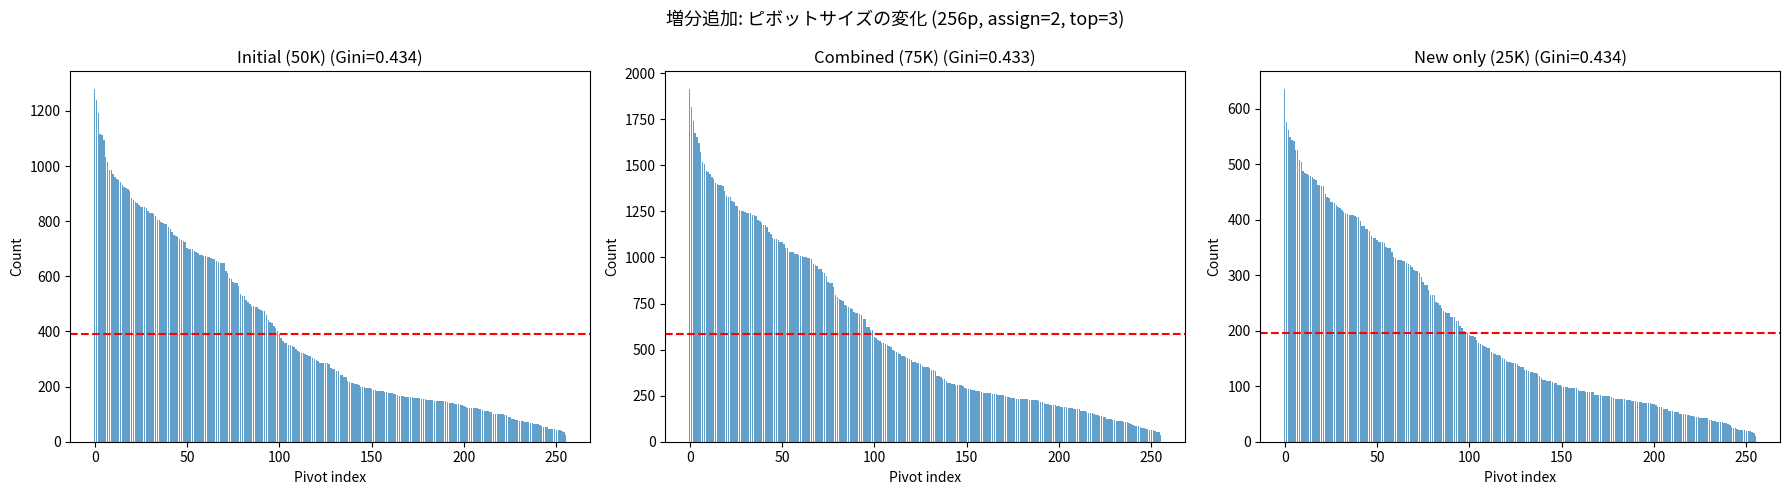

In [11]:
# --- Gini 係数の比較: 初期 vs 追加後 ---
def compute_gini(sizes):
    sizes_arr = np.array(sizes, dtype=float)
    n = len(sizes_arr)
    sorted_s = np.sort(sizes_arr)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_s) - (n + 1) * np.sum(sorted_s)) / (n * np.sum(sorted_s))

n_top_ref = 3  # 代表構成

gini_initial = compute_gini(phase_results["Initial (50K)"][n_top_ref]["pivot_sizes"])
gini_combined = compute_gini(phase_results["Combined (75K)"][n_top_ref]["pivot_sizes"])

print(f"ピボットサイズ Gini 係数 (top={n_top_ref}):")
print(f"  Initial (50K): {gini_initial:.4f}")
print(f"  Combined (75K): {gini_combined:.4f}")
print(f"  変化: {gini_combined - gini_initial:+.4f}")

# ピボットサイズ変化の可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (phase_name, n_top_val) in zip(axes, [
    ("Initial (50K)", n_top_ref), ("Combined (75K)", n_top_ref), ("New only (25K)", n_top_ref)
]):
    sizes = sorted(phase_results[phase_name][n_top_val]["pivot_sizes"], reverse=True)
    ax.bar(range(len(sizes)), sizes, alpha=0.7)
    ax.axhline(y=np.mean(sizes), color='red', linestyle='--')
    gini = compute_gini(sizes)
    ax.set_title(f'{phase_name} (Gini={gini:.3f})')
    ax.set_xlabel("Pivot index")
    ax.set_ylabel("Count")

plt.suptitle(f"増分追加: ピボットサイズの変化 ({N_PIVOTS}p, assign={N_ASSIGN}, top={n_top_ref})", fontsize=13)
plt.tight_layout()
plt.savefig("../data/voronoi_incremental_pivot_sizes.png", dpi=150, bbox_inches='tight')
plt.show()

## ピボットデータのエクスポート（NB103 JS実験用）

全データ（75K件）で k-means ピボットを学習し、ピボットセントロイドと割り当て情報を JSON にエクスポートする。

In [12]:
# --- 全データでピボット学習 & エクスポート ---
kmeans_full = MiniBatchKMeans(n_clusters=N_PIVOTS, random_state=42, batch_size=2048, n_init=3)
kmeans_full.fit(embeddings_normed)
centroids_full = kmeans_full.cluster_centers_
centroids_full_normed = centroids_full / np.linalg.norm(centroids_full, axis=1, keepdims=True)

# ピボットセントロイドをエクスポート
pivots_data = {
    "n_pivots": N_PIVOTS,
    "dim": int(centroids_full_normed.shape[1]),
    "centroids": centroids_full_normed.tolist(),
}
pivots_path = Path("../data/voronoi_pivots.json")
with open(pivots_path, "w") as f:
    json.dump(pivots_data, f)
print(f"ピボット保存: {pivots_path} ({pivots_path.stat().st_size / 1024:.0f} KB)")

# 割り当て情報をエクスポート
all_pivot_sims_full = embeddings_normed @ centroids_full_normed.T
assignments = {}
for i in range(N_DATA):
    top_pivots = np.argsort(-all_pivot_sims_full[i])[:N_ASSIGN]
    assignments[face_ids[i]] = [int(p) for p in top_pivots]

assignments_data = {
    "n_assign": N_ASSIGN,
    "n_pivots": N_PIVOTS,
    "n_faces": N_DATA,
    "assignments": assignments,
}
assignments_path = Path("../data/voronoi_assignments.json")
with open(assignments_path, "w") as f:
    json.dump(assignments_data, f)
print(f"割り当て保存: {assignments_path} ({assignments_path.stat().st_size / 1024 / 1024:.1f} MB)")

# 検証用: クエリとGround Truthもエクスポート
all_queries = []
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for q_idx in members:
        gt_face_ids = [face_ids[m] for m in members if m != q_idx]
        all_queries.append({
            "query_face_id": face_ids[q_idx],
            "cluster_id": int(cid),
            "gt_face_ids": gt_face_ids,
        })

# ブルートフォース Top-30 も保存（JS 検証用）
all_gt_bf = []
for q_info in all_queries:
    q_idx = face_ids.index(q_info["query_face_id"])
    q_emb = embeddings_normed[q_idx]
    sims = embeddings_normed @ q_emb
    sims[q_idx] = -1
    top30_indices = np.argsort(-sims)[:30]
    all_gt_bf.append({
        "query_face_id": q_info["query_face_id"],
        "top30": [{"face_id": face_ids[i], "score": float(sims[i])} for i in top30_indices],
    })

verification_data = {
    "queries": all_queries,
    "bf_top30": all_gt_bf,
    "face_ids": face_ids,
}
verif_path = Path("../data/voronoi_verification.json")
with open(verif_path, "w") as f:
    json.dump(verification_data, f)
print(f"検証データ保存: {verif_path} ({verif_path.stat().st_size / 1024 / 1024:.1f} MB)")

ピボット保存: ../data/voronoi_pivots.json (2817 KB)


割り当て保存: ../data/voronoi_assignments.json (3.7 MB)


検証データ保存: ../data/voronoi_verification.json (3.4 MB)


In [ ]:
# --- 全 embedding をバイナリ形式でエクスポート（JS cosine rerank 検証用）---
# JSON は 810MB で Node.js 文字列長制限を超えるため、Float32 バイナリ + face_id リストで保存

# face_ids の順序を保存
face_ids_path = Path("../data/voronoi_face_ids.json")
with open(face_ids_path, "w") as f:
    json.dump(face_ids, f)
print(f"Face IDs 保存: {face_ids_path} ({face_ids_path.stat().st_size / 1024 / 1024:.1f} MB)")

# embedding を Float32 バイナリで保存（face_ids と同じ順序）
emb_bin_path = Path("../data/voronoi_embeddings.bin")
embeddings_normed.tofile(str(emb_bin_path))
print(f"Embedding バイナリ保存: {emb_bin_path} ({emb_bin_path.stat().st_size / 1024 / 1024:.1f} MB)")
print(f"  shape: {embeddings_normed.shape}, dtype: {embeddings_normed.dtype}")

# 古い JSON 版を削除
old_json = Path("../data/voronoi_embeddings.json")
if old_json.exists():
    old_json.unlink()
    print(f"  旧 JSON 版を削除: {old_json}")

## 総合考察

### 実験1: Train/Test 分割テスト
- 60%の学習データで作成したピボットがテストデータに対しても同等の精度を維持するか確認
- **成功基準**: テストセットの BF-R@30 >= 学習セットの 95%

### 実験2: 増分データ追加
- 50K件で学習したピボットに25K件を新規追加
- ピボット再学習なしで精度が維持されるか確認
- **成功基準**: Gini 係数が大きく変化しない

### エクスポートデータ（NB103 用）
- `data/voronoi_pivots.json`: 256ピボットのセントロイド（256 x 512-D）
- `data/voronoi_assignments.json`: 各 face_id のピボット割り当て
- `data/voronoi_embeddings.json`: 全 face の正規化済み embedding
- `data/voronoi_verification.json`: クエリ・GT 情報（Python 結果との照合用）